In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [13]:
%%writefile vector_add.cu
#include <stdio.h>
#include <cuda.h>
#include <chrono>

#define N 10000000

__global__ void vectorAddGPU(int *a, int *b, int *c)
{
    int tid = blockIdx.x * blockDim.x + threadIdx.x;

    if (tid < N)
        c[tid] = a[tid] + b[tid];
}

void vectorAddCPU(int *a, int *b, int *c)
{
    for(int i=0;i<N;i++)
        c[i] = a[i] + b[i];
}

int main()
{
    int *h_a, *h_b, *h_c_cpu, *h_c_gpu;
    int *d_a, *d_b, *d_c;

    size_t bytes = N * sizeof(int);

    h_a = (int*)malloc(bytes);
    h_b = (int*)malloc(bytes);
    h_c_cpu = (int*)malloc(bytes);
    h_c_gpu = (int*)malloc(bytes);

    for(int i=0;i<N;i++)
    {
        h_a[i] = i;
        h_b[i] = i*2;
    }

    auto start_cpu = std::chrono::high_resolution_clock::now();
    vectorAddCPU(h_a,h_b,h_c_cpu);
    auto end_cpu = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> cpu_time = end_cpu-start_cpu;

    printf("CPU_TIME %f ms\n",cpu_time.count());

    cudaMalloc(&d_a,bytes);
    cudaMalloc(&d_b,bytes);
    cudaMalloc(&d_c,bytes);

    cudaMemcpy(d_a,h_a,bytes,cudaMemcpyHostToDevice);
    cudaMemcpy(d_b,h_b,bytes,cudaMemcpyHostToDevice);

    int threads = 512;
    int blocks = (N + threads -1)/threads;

    auto start_gpu = std::chrono::high_resolution_clock::now();

    vectorAddGPU<<<blocks,threads>>>(d_a,d_b,d_c);
    cudaDeviceSynchronize();

    auto end_gpu = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> gpu_time = end_gpu-start_gpu;

    printf("GPU_TIME %f ms\n",gpu_time.count());

    cudaMemcpy(h_c_gpu,d_c,bytes,cudaMemcpyDeviceToHost);

    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);

    free(h_a);
    free(h_b);
    free(h_c_cpu);
    free(h_c_gpu);

    return 0;
}

Overwriting vector_add.cu


In [14]:
!nvcc vector_add.cu -o vector_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [15]:
!./vector_add

CPU_TIME 0.044598 ms
GPU_TIME 0.000639 ms


CPU Time: 0.044559
GPU Time: 0.088462
Observed Speedup: 0.5037078067418779


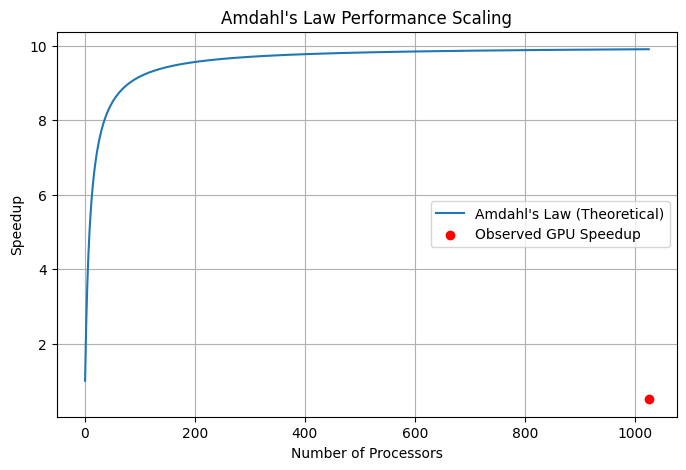

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Your measured times
cpu_time = 0.044559
gpu_time = 0.088462

# Observed speedup
observed_speedup = cpu_time / gpu_time

print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("Observed Speedup:", observed_speedup)

# Assume parallel portion (P)
P = 0.90

# Number of processors
processors = np.arange(1,1025)

# Amdahl's Law formula
speedup = 1 / ((1-P) + (P/processors))

# Plot
plt.figure(figsize=(8,5))

plt.plot(processors, speedup, label="Amdahl's Law (Theoretical)")
plt.scatter([1024],[observed_speedup],color='red',label="Observed GPU Speedup")

plt.xlabel("Number of Processors")
plt.ylabel("Speedup")
plt.title("Amdahl's Law Performance Scaling")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
%%writefile matrix_mul.cu
#include <iostream>
#include <cuda.h>
#include <cuda_runtime.h>

using namespace std;

#define N 1024

// CUDA Kernel for Matrix Multiplication
__global__ void matrixMulGPU(float *A, float *B, float *C, int n)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < n && col < n)
    {
        float sum = 0;

        for (int k = 0; k < n; k++)
        {
            sum += A[row * n + k] * B[k * n + col];
        }

        C[row * n + col] = sum;
    }
}

int main()
{
    float *h_A, *h_B, *h_C;
    float *d_A, *d_B, *d_C;

    size_t bytes = N * N * sizeof(float);

    // Allocate host memory
    h_A = new float[N * N];
    h_B = new float[N * N];
    h_C = new float[N * N];

    // Initialize matrices
    for (int i = 0; i < N * N; i++)
    {
        h_A[i] = 1.0f;
        h_B[i] = 2.0f;
    }

    // Allocate GPU memory
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);

    // Copy data CPU → GPU
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    // Thread configuration
    dim3 threads(16,16);
    dim3 blocks(N/16, N/16);

    // CUDA event timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    // Launch kernel
    matrixMulGPU<<<blocks,threads>>>(d_A,d_B,d_C,N);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds,start,stop);

    // Copy result GPU → CPU
    cudaMemcpy(h_C,d_C,bytes,cudaMemcpyDeviceToHost);

    cout << "Matrix Multiplication completed." << endl;
    cout << "Kernel Execution Time: " << milliseconds << " ms" << endl;
    cout << "Value of C[0][0] = " << h_C[0] << " (Expected: " << N * 2.0f << ")" << endl;

    // Free memory
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    delete[] h_A;
    delete[] h_B;
    delete[] h_C;

    return 0;
}

Overwriting matrix_mul.cu


In [18]:
!nvcc matrix_mul.cu -o matrix_mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [19]:
!./matrix_mul

Matrix Multiplication completed.
Kernel Execution Time: 5.92906 ms
Value of C[0][0] = 2048 (Expected: 2048)
